# EXOPLANET CLUSTERING PROJECT
## Kaggle Dataset: Exoplanets - Planets Outside Our Galaxy
Author: Chase Patterson

# Introduction and Problem Definition
In this project I aim to explore data on exoplanets - planets that exist outside of our solar system - and to use clustering techniques to hopefully identify natural groups of planets based on their physical and also orbital characteristics!

## Main Question I aim to Answer:
Can we group exoplanets into categories (small rocky planets,gas giants, hot Jupiters) using clustering based on measurable features like mass, radius, and orbital period?

Clustering algorithms such as k-means and hierarchical clustering will help uncover hidden patterns in exoplanet data.

# What Is Clustering?
### Clustering can be defined as an unsupervised learning technique which groups similar data points into clusters. The two main types:
 - K-Means: Divides data into k clusters by minimizing the cluster distances.
 - Hierarchical: This merges points in an orderly way based on similarity.

## The Goal: Reveal families of planets with similar features!

# Dataset Overview
## Key features include:
 1. **Name:** Identifier of the exoplanet
 2. **Mass (MJ):** Planetary mass in Jupiter masses
 3. **Radius (RJ):** Planetary radius 
 4. **Period (days):** Orbital period in days
 5. **Semi-major axis (AU):** Average orbital distance from the host star
 6. **Temp. (K):** Estimated surface temperature of the planet
 7. **Disc. Year:** Year of discovery
 8. **Distance (ly):** Distance from Earth in light years
 9. **Host star mass (M):** Mass of the host star in solar masses
 10. **Temp. (K):** Surface temperature of the planet
 11. **Remarks:** Comments about the planet
### These features will be used for clustering analysis.


# Data Laoding & Libraries

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

## Data Set Overview

In [5]:
file_path = "/Users/chasepatterson/Library/Mobile Documents/com~apple~CloudDocs/archive (1).zip"  # You can adjust this path
df = pd.read_csv(file_path)
print("\nOriginal dataset shape:", df.shape)
print(df.head())
print(df.info())
print(df.describe())

                 Name Mass (MJ) Radius (RJ) Period (days)  \
0         16 Cygni Bb      2.38         NaN         799.5   
1         23 Librae b      1.61         NaN        258.18   
2  47 Ursae Majoris b      2.53         NaN          1078   
3         51 Pegasi b      0.46         NaN      4.230785   
4         55 Cancri b    0.8306         NaN      14.65152   

  Semi-major axis (AU) Temp. (K) Discovery method  Disc. Year Distance (ly)  \
0                 1.66       NaN      radial vel.      1996.0         68.99   
1                 0.81       NaN      radial vel.      1999.0         85.46   
2                  2.1       NaN      radial vel.      1996.0         45.02   
3               0.0527       NaN      radial vel.      1995.0         50.45   
4             0.115227       700      radial vel.      1996.0         41.06   

  Host star mass (M☉) Host star temp. (K)  \
0                1.04                5750   
1                1.07                5736   
2                1.08  

In [10]:
import numpy as np  # For the numeric handling and NaN support

numeric_features = [
    'Mass (MJ)', 'Radius (RJ)', 'Period (days)', 'Semi-major axis (AU)',
    'Temp. (K)', 'Distance (ly)', 'Host star mass (M☉)', 'Host star temp. (K)'
]

# I aim to clean non numeric entries (e.g., symbols, uncertainty values)
def clean_numeric(x):
    if isinstance(x, str):
        x = x.replace("±", " ").replace("+", " ").replace("~", " ").replace(",", "").strip()
        x = x.replace("—", "").replace("-", " ")
        parts = x.split()
        for part in parts:
            try:
                return float(part)
            except ValueError:
                continue
        return np.nan
    return x

# Apply cleaning across numeric columns
for col in numeric_features:
    df[col] = df[col].apply(clean_numeric)

# Here I wan to remove rows missing too many values and then fill remaining gaps with column means
df_clean = df[numeric_features].dropna(thresh=len(numeric_features) - 3)
df_clean = df_clean.fillna(df_clean.mean())

print("\nCleaned dataset shape:", df_clean.shape)
print(df_clean.head())




Cleaned dataset shape: (4551, 8)
   Mass (MJ)  Radius (RJ)  Period (days)  Semi-major axis (AU)    Temp. (K)  \
0     2.3800     0.406375     799.500000              1.660000  1099.541616   
1     1.6100     0.406375     258.180000              0.810000  1099.541616   
2     2.5300     0.406375    1078.000000              2.100000  1099.541616   
3     0.4600     0.406375       4.230785              0.052700  1099.541616   
4     0.8306     0.406375      14.651520              0.115227   700.000000   

   Distance (ly)  Host star mass (M☉)  Host star temp. (K)  
0          68.99                1.040               5750.0  
1          85.46                1.070               5736.0  
2          45.02                1.080               5892.0  
3          50.45                1.120               5793.0  
4          41.06                0.905               5196.0  


# Exploratory Data Analysis

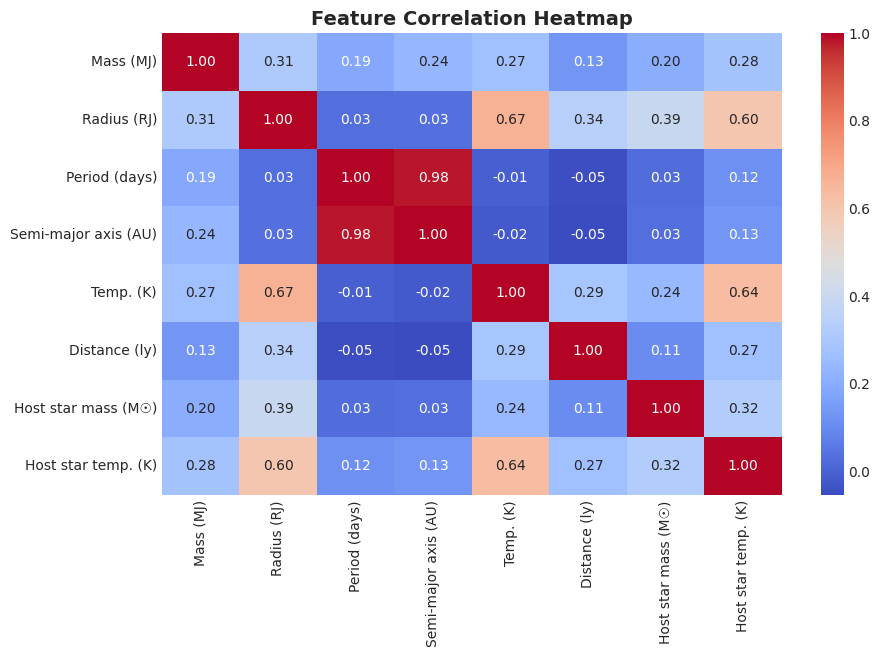

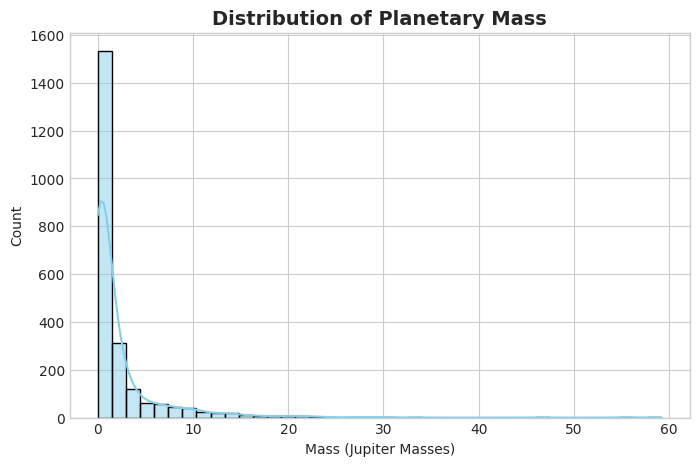

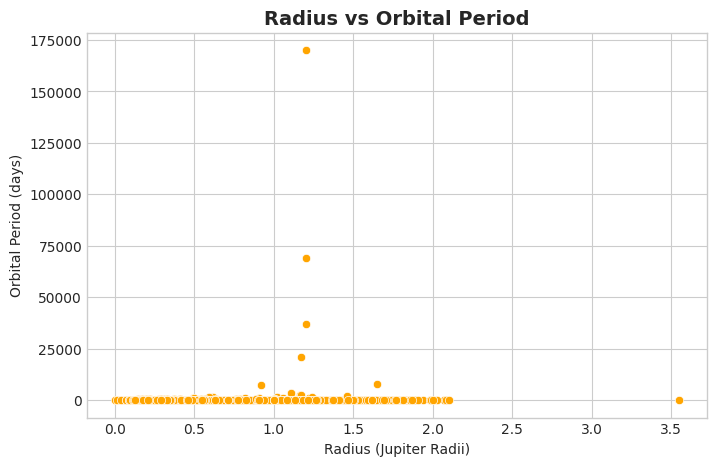

In [18]:
plt.style.use("seaborn-v0_8-whitegrid")  # Set clean plotting style
plt.rcParams['font.family'] = 'DejaVu Sans' # Supports the font issue for a data point 


# Correlation heatmap helps reveal relationships between planetary and stellar features.
numeric_features = ['Mass (MJ)', 'Radius (RJ)', 'Period (days)', 'Semi-major axis (AU)',
                    'Temp. (K)', 'Distance (ly)', 'Host star mass (M☉)', 'Host star temp. (K)']
df_clean = df[numeric_features].dropna()  # Use only complete rows for correlation for better use

plt.figure(figsize=(10, 6))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap", fontsize=14, weight="bold")
plt.show()

# This plot shows how planetary mass is distributed across the dataset.
# It highlights that most planets are small with a few massive outliers.
plt.figure(figsize=(8, 5))
sns.histplot(df['Mass (MJ)'], bins=40, kde=True, color='skyblue')
plt.title("Distribution of Planetary Mass", fontsize=14, weight="bold")
plt.xlabel("Mass (Jupiter Masses)")
plt.show()

# This scatter plot compares planet size to orbital period.
# It aims to help visualize patterns and then also detect clusters or outliers.
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Radius (RJ)', y='Period (days)', data=df, color='orange')
plt.title("Radius vs Orbital Period", fontsize=14, weight="bold")
plt.xlabel("Radius (Jupiter Radii)")
plt.ylabel("Orbital Period (days)")
plt.show()


## Visualization Insights:
## 1. Feature Correlation Heatmap
This chart shows how different planet and star features are related to each other. The strongest relationship shown is between a planet’s orbital distance and its orbital period. This means planets farther from their star take longer to orbit. Planet size and temperature also show a strong connection and likely because many larger planets in the dataset orbit close to their stars and therefore heat up in temp.
## 2. Mass Distribution Histogram
This graph shows that most planets in the dataset have relatively low mass and with only a small number being extremely large. The distribution is seems very uneven with many small planets and only a few massive ones. The rare very large planets could affect clustering so they may need special handling or possible scaling.
## 3. Radius vs. Orbital Period Scatter Plot
This chart compares how big a planet is to how long it takes to orbit its star. Most planets in the dataset orbit quickly and are medium to large in size. This reflects that these types of planets are easier for us to detect. A few planets have very long orbital periods and appear as outliers which shows that rare planets also exist in the dataset.

# Preprocessing Data

In [13]:
# Here I wnat tp scale numeric data to standardize feature ranges before clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)

# Then to apply PCA to reduce data to 2D for visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# K-Means Clustering

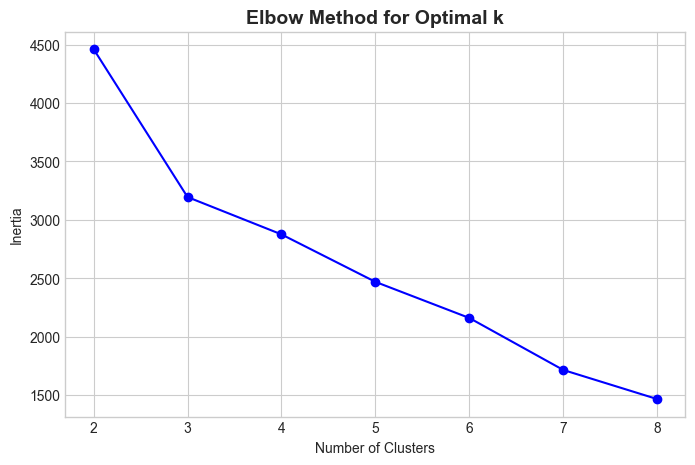

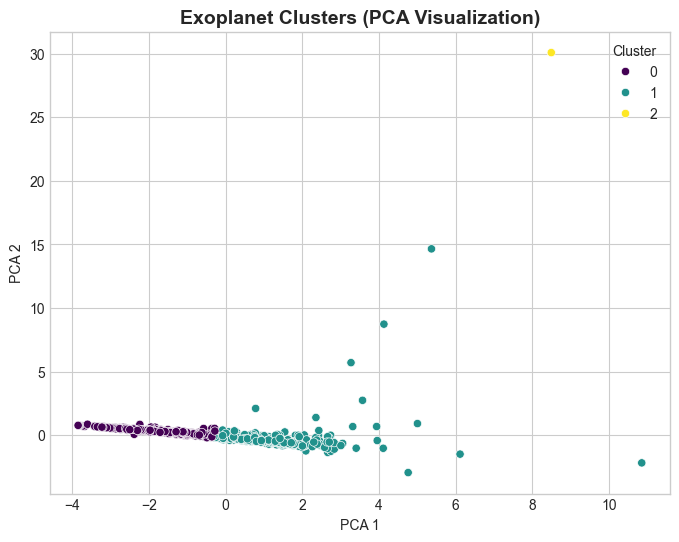

In [14]:
# This will determine optimal number of clusters using the Elbow Method
inertia = []
K = range(2, 9)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plots the elbow curve to visualize clustering performance and find optimal number
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.title("Elbow Method for Optimal k", fontsize=14, weight="bold")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Fits the K-Means with 3 clusters which are based on elbow result
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)
df_clean['Cluster'] = clusters  # add cluster labels to dataset

# Visualizes clusters in PCA reduced 2D space
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=clusters, palette='viridis')
plt.title("Exoplanet Clusters (PCA Visualization)", fontsize=14, weight="bold")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.show()


## Elbow Method for Optimal k
This graph shows how the inertia or clustering error decreases as we increase the number of clusters. The biggest drop happens between k = 2 and k = 3, and after that, the line starts to flatten out. This suggests that 3 clusters is a good choice because adding more clusters does not significantly improve the grouping.
## Exoplanet Clusters (PCA Visualization)
This scatter plot shows how the planets were grouped into clusters after reducing the data to two main dimensions (PCA 1 and PCA 2). We can see three distinct groups and  showing that the clustering algorithm successfully separated planets with different characteristics. Cluster one appears tightly packed, two is more spread out, and the third contains a few extreme values, suggesting different types or categories of planets in the dataset.


# Hierarchical Clustering

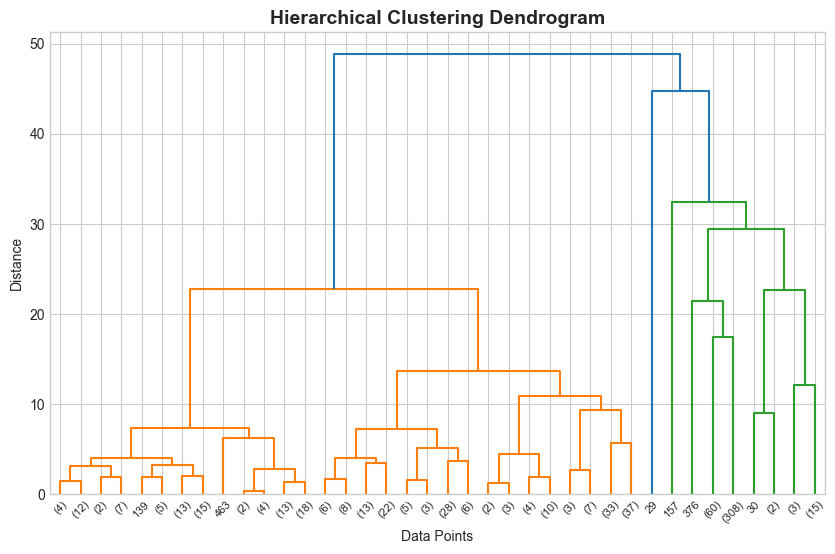

In [15]:
# This is the hierarchical clustering
linked = linkage(scaled_data, method='ward')

# Plots the dendrogram to visualize any relationships
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram", fontsize=14, weight="bold")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

## Hierarchical Clustering Dendrogram
This dendrogram shows how the exoplanets group together based on their similarity. Here we can see the shorter branches representing planets that are more alike. In the graph, we can see three major cluster splits at higher distance levels thus meaning the dataset naturally forms three distinct groups. Because those three branches separate clearly before the large jumps in distance, this confirms that three clusters is an appropriate and meaningful choice for this dataset! :) 

# Cluster Summary Table


--- Cluster Summary ---

         Mass (MJ)  Radius (RJ)  Period (days)  Semi-major axis (AU)  \
Cluster                                                                
0             0.31         0.45          19.97                  0.11   
1             1.95         1.28         346.64                  0.29   
2             7.00         1.20      170000.00                 68.00   

         Temp. (K)  Distance (ly)  Host star mass (M☉)  Host star temp. (K)  
Cluster                                                                      
0           784.28         537.50                 0.76              4699.67  
1          1556.83        1533.61                 1.28              5981.67  
2          1200.00         128.51                 1.51              7400.00  


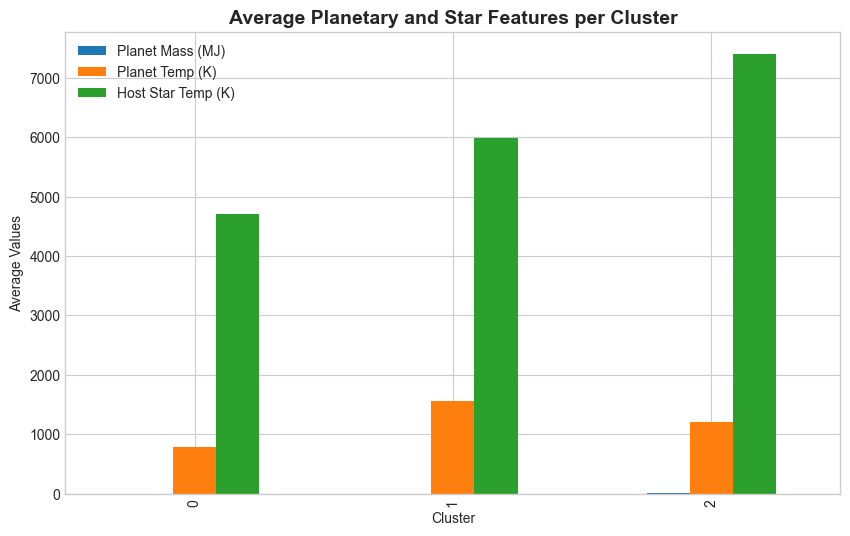

In [16]:
# Calculates the average feature values for each cluster
summary = df_clean.groupby('Cluster')[numeric_features].mean().round(2)
print("\n--- Cluster Summary ---\n")
print(summary)
summary_plot = summary[['Mass (MJ)', 'Temp. (K)', 'Host star temp. (K)']]

# Finally I can plot average planetary and star features by cluster fro final insights
summary_plot.plot(kind='bar', figsize=(10, 6))
plt.title("Average Planetary and Star Features per Cluster", fontsize=14, weight="bold")
plt.xlabel("Cluster")
plt.ylabel("Average Values")
plt.legend(["Planet Mass (MJ)", "Planet Temp (K)", "Host Star Temp (K)"])
plt.show()


## Average Planetary and Star Features per Cluster Interpretation
The summary table and bar chart show how the planets in the dataset grouped into three different categories based on their mass and temperatures. One group contains small and cooler planets that orbit smaller, cooler stars, meaning they are likely more calm and stable environments. Another group contains large and very hot planets that orbit very close to bright, hot stars, which makes them heat up a lot, these are known as Hot Jupiters. The final group contains very large planets that orbit far away from their stars, so even though their stars are hot, these planets stay relatively cooler and take a very long time to complete one orbit. I belive that overall, the clustering shows that planets naturally fall into clear types based on how big they are and how close they are to their stars.

## Storytelling and Clustering Analysis:

### After visualizing the data, the clustering results provide a deeper understanding of how exoplanets can be grouped based on their shared physical and orbital characteristics.  
### Using K-Means clustering with k = 3 (from the elbow method!), I identified three distinct types of exoplanets in the dataset.

### Cluster 1 - Hot, Massive Giants (The Close Orbiting Planets)
These planets are large, high temperature worlds with short orbital periods. They are most likely Hot Jupiters, gas giants orbiting very close to their stars, which causes extreme surface temperatures.  
They dominate the dataset because they are easier to detect using current astronomical methods such as the transit and radial velocity techniques.

### Cluster 2 - Medium, Temperate Planets (Moderate Orbit)
This group represents planets with mid-range masses and radii that orbit their stars at moderate distances.  
They resemble gas or ice giants like Saturn or Neptune, existing in more stable systems and showing balanced temperature and distance profiles.

### Cluster 3 - The Small, Cold, and Distant Planets
The third cluster contains the lower mass, cooler planets orbiting far from their host stars.  
These planets are harder to detect because of their long orbital periods and faint signals, but they may represent Earth-sized or icy planets that expand our understanding of outer system formation.

## Insights & Learnings
### Several important insights emerged from the clustering analysis:

- Detection Bias in Data:  
  Based on References the most known exoplanets are large and close to their stars because current technology detects them more easily. This creates an observational bias that favors hot, massive planets.

- Natural Structure in Populations:  
  The clear separation between large, hot planets and small, cold ones indicates that the dataset reflects astrophysical trends rather than random variation. (Real Data Theories!)

- Potential for Future Classification:
  The clustering model could help classify newly discovered exoplanets into categories automatically based on measurable properties such as the mass, radius, and orbital characteristics that were present in this dataset. 

These insights show that unsupervised learning can reveal natural patterns in space data and thus supporting deeper exploration of how planetary systems form. :)

## Ethical & Societal Impact

### While this project focuses on space rather than people I beleve it can still raises relevant ethical considerations:

- Data Bias:  
The dataset favors planets that are easier to detect. This can distort our overall picture of planetary diversity and influence scientific conclusions possibly!

- Scientific Transparency: 
Clustering does not prove physical categories. It reveals patterns. Scientists and communicators must avoid overstating these findings to the public.

- Societal Value:  
Clustering analysis can eventually assist in identifying potentially habitable planets and guide future missions.

By recognizing both the promise and limitations of our models I think we ensure that this type of research remains scientifically responsible and escpecially ethically aware.


## Conclusion

### This project applied clustering methods to uncover natural groupings among exoplanets outside our solar system.  
Through cleaning, visualization, and modeling, I found that:

- The dataset naturally forms three major clusters of exoplanets.  
- The patterns between temperature, distance, and mass align with real astrophysical theories.  
- Clustering provides a valuable way to explore unlabeled astronomical data and uncover hidden structure.

This project demonstrates how data mining and astrophysics intersect thus allowing us to understand our universe through data driven exploration. I hope you enjoyed and learned something new! Thank you for taking the time to read through! :)


## References:

Diaa Essam. (2025). Exoplanets – Planets outside our galaxy [Data set]. Kaggle. https://www.kaggle.com/datasets/diaaessam/exoplanets-planets-outside-our-galaxy

NASA. (2025). Exoplanet archive: Data and tools for exoplanet research. NASA/IPAC. https://exoplanetarchive.ipac.caltech.edu/

NASA. (2025). Exoplanets: A continuously updated resource for confirmed planets. NASA Science. https://science.nasa.gov/exoplanets/

Zhu, W., & Dong, S. (2021). Exoplanet statistics and theoretical implications. Annual Review of Astronomy and Astrophysics, 59, 1–36. https://doi.org/10.1146/annurev-astro-112420-020055

Akeson, R. L., Chen, X., Ciardi, D., et al. (2013). The NASA exoplanet archive: Data and tools for exoplanet research. arXiv preprint. https://arxiv.org/abs/1307.2944

OpenAI. (2025). About OpenAI – advancing artificial intelligence for data analysis. https://openai.com